In [114]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

control = pd.read_csv("df_control.csv")
test = pd.read_csv("df_test.csv")

control.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation,visitor_id,visit_id,process_step,date_time
0,1028,12.0,145.0,36.0,M,3.0,103520.22,1.0,4.0,Control,42237450_62128060588,557292053_87239438319_391157,step_1,2017-04-08 19:00:26
1,1028,12.0,145.0,36.0,M,3.0,103520.22,1.0,4.0,Control,42237450_62128060588,557292053_87239438319_391157,step_2,2017-04-08 19:00:17
2,1028,12.0,145.0,36.0,M,3.0,103520.22,1.0,4.0,Control,42237450_62128060588,557292053_87239438319_391157,step_1,2017-04-08 19:00:15
3,1028,12.0,145.0,36.0,M,3.0,103520.22,1.0,4.0,Control,42237450_62128060588,557292053_87239438319_391157,step_1,2017-04-08 18:59:55
4,1028,12.0,145.0,36.0,M,3.0,103520.22,1.0,4.0,Control,42237450_62128060588,557292053_87239438319_391157,step_3,2017-04-08 18:58:04


### COMPLETION RATES BETWEEN TEST AND CONTROL GROUPS


#### What % of users finished the entire process?

To answer this question, the goal was to measure how many unique users successfully reached the final step of the process (“confirm”), and express that as a percentage of all users who started the online process.

**Approach:**

The analysis is based on two key ideas:

1. Identify total users who entered the process

2. Identify how many of those users reached the final step (“confirm”)

By comparing these two numbers, we can compute the completion rate, which represents the proportion of users who successfully finished the process. 

**Assumptions:**

In order to calculate the completion rate we assumed the following: 

1. visit_id represents a unique user
2. Reaching "confirm" = full completion
3. Users are counted only once
4. All users had the opportunity to complete 

In [121]:
def completion_var(df):
    total = df["visit_id"].nunique()
    completed = df[df["process_step"]=="confirm"]["visit_id"].nunique()
    return len(completed)
    
def completion_rate(completed: int, total: int, label=""):
    if total == 0:
        return 0
    else:
        completion_rate = (completed/total)*100
    print(f"Completion rate {label}: {completion_rate:.2f}%")
    return completion_rate 


comp_test = completed_num(test)
comp_control = completed_num(control)


rate_test = completion_rate(comp_test, total_test, "test group")
rate_control = completion_rate(comp_control, total_control, "control group")


def relative_change(control, test): 
    relative_change = ((test-control)/control)*100
    print(f"The relative change from {control} to {test} is {relative_change:.2f}%")
    return relative_change

Completion rate test group: 95.38%
Completion rate control group: 74.39%


### COMPLETION RATES WITHIN GROUPS 

#### WITHIN CONTROL GROUP 

Answers: Of users who reached "step" how many finished it?”

In [84]:
def step_completion_rates(df, steps):
    results = []
    
    for i in range(len(steps)):
        step = steps[i]
        
        if i == 0:
            started_users = df["visit_id"].nunique()
        else:
            prev_step = steps[i-1]
            started_users = df[df["process_step"] == prev_step]["visit_id"].nunique()
        
        completed_users = df[df["process_step"] == step]["visit_id"].nunique()
        
        rate = (completed_users / started_users) * 100 if started_users != 0 else 0
        
        results.append({
            "step": step,
            "started": started_users,
            "completed": completed_users,
            "completion_rate": round(rate, 2)})
    
    return results

In [85]:
steps = ["start", "step_1", "step_2","step_3", "confirm"]

control_cr_steps = step_completion_rates(control, steps)
control_cr_steps 

[{'step': 'start',
  'started': 32189,
  'completed': 30910,
  'completion_rate': 96.03},
 {'step': 'step_1',
  'started': 30910,
  'completed': 23548,
  'completion_rate': 76.18},
 {'step': 'step_2',
  'started': 23548,
  'completed': 20138,
  'completion_rate': 85.52},
 {'step': 'step_3',
  'started': 20138,
  'completed': 18300,
  'completion_rate': 90.87},
 {'step': 'confirm',
  'started': 18300,
  'completed': 16046,
  'completion_rate': 87.68}]

#### WITHIN TEST GROUP

In [86]:
test_cr_steps = step_completion_rates(test, steps)
test_cr_steps

[{'step': 'start',
  'started': 37136,
  'completed': 33157,
  'completion_rate': 89.29},
 {'step': 'step_1',
  'started': 33157,
  'completed': 28285,
  'completion_rate': 85.31},
 {'step': 'step_2',
  'started': 28285,
  'completed': 24503,
  'completion_rate': 86.63},
 {'step': 'step_3',
  'started': 24503,
  'completed': 22186,
  'completion_rate': 90.54},
 {'step': 'confirm',
  'started': 22186,
  'completed': 21731,
  'completion_rate': 97.95}]

In [91]:
control_df = pd.DataFrame(control_cr_steps)
test_df = pd.DataFrame(test_cr_steps)

cr_df = control_df.merge(test_df, on="step", suffixes=("_control", "_test"))
cr_df

,step,started_control,completed_control,completion_rate_control,started_test,completed_test,completion_rate_test
0,start,32189,30910,96.03,37136,33157,89.29
1,step_1,30910,23548,76.18,33157,28285,85.31
2,step_2,23548,20138,85.52,28285,24503,86.63
3,step_3,20138,18300,90.87,24503,22186,90.54
4,confirm,18300,16046,87.68,22186,21731,97.95


In [112]:
cr_df["abs_diff"] = abs(cr_df["completion_rate_test"] - cr_df["completion_rate_control"])
cr_df["rel_diff"] = cr_df["abs_diff"] / cr_df["completion_rate_control"] * 100

cr_df[["step", "completion_rate_control", "completion_rate_test", "abs_diff", "rel_diff"]]

,step,completion_rate_control,completion_rate_test,abs_diff,rel_diff
0,start,96.03,89.29,6.74,7.018640
1,step_1,76.18,85.31,9.13,11.984773
2,step_2,85.52,86.63,1.11,1.297942
3,step_3,90.87,90.54,0.33,0.363156
4,confirm,87.68,97.95,10.27,11.713047


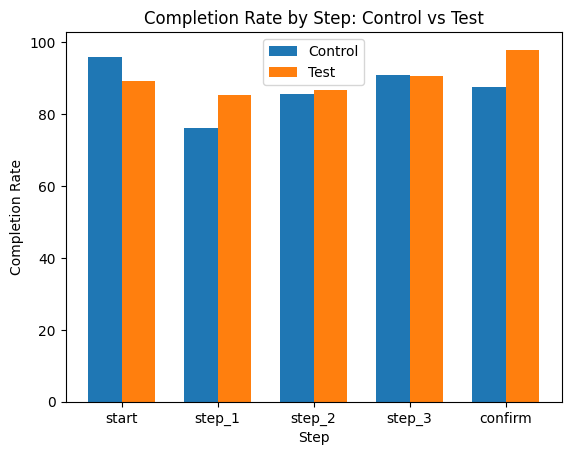

In [104]:
steps = cr_df['step']
control = cr_df['completion_rate_control']
test = cr_df['completion_rate_test']

x = np.arange(len(steps))
width = 0.35

plt.bar(x - width/2, control, width, label='Control')
plt.bar(x + width/2, test, width, label='Test')

plt.xticks(x, steps)
plt.ylabel('Completion Rate')
plt.xlabel('Step')
plt.title('Completion Rate by Step: Control vs Test')
plt.legend()

plt.show()

TypeError: unhashable type: 'numpy.ndarray'

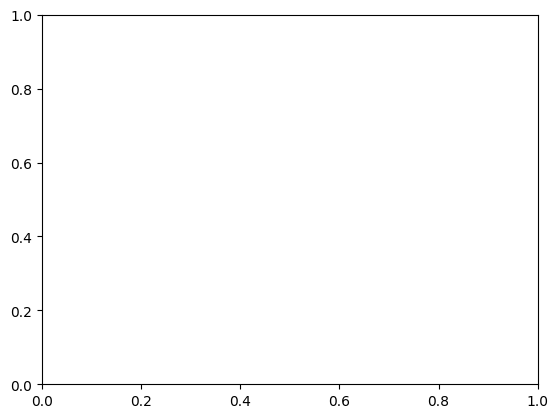

In [111]:
diff = cr_df["rel_diff"]

x = np.arange(len(steps))
width = 0.35

plt.bar(x - width/2, cr_df, width, label='Control')

plt.xticks(x, steps)
plt.ylabel('Completion Rate')
plt.xlabel('Step')
plt.title('Completion Rate by Step: Control vs Test')
plt.legend()

plt.show()

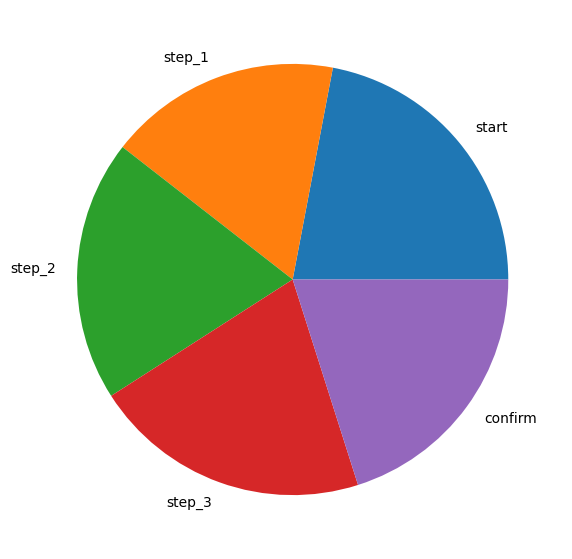

In [108]:
fig = plt.figure(figsize=(10, 7))
plt.pie(y, labels=mylabels)

# show plot
plt.show()